# Cross Sectional Momentum Portfolio 
### By Danny Salib 

### Getting Started

In [1]:
from pathlib import Path
import pickle as pkl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from csm.config import Config, Param
from csm.state import State
from csm.universe import Universe
from csm.signals import Signal, PortfolioBuilder
from csm.data import download_data
from csm.backtest import build_signal, compute_backtest_returns
from csm.risk import compute_volatility_managed_returns
from csm.performance import compute_performance_stats, log_performance_table
from csm.plotting import plot_perf

In [20]:
plt.style.use('fivethirtyeight')

### Creating configuration and state machine 

In [3]:
# TODO explain what you mean here

In [4]:
cfg = Config()
state = State()

### Stock Selection Aalysis

##### Universe implementation 
At first I was using the SP500 stocks as my universe, but I want to take a more academic approach. The problem is, academics don't care about tradeable stocks, and care more about broad stroke anomlies that may exist in the world. To bridge this gap, I'll swap the SP500 stocks for a larger universe: NASDAQ

In [5]:
# TODO talk about this

In [6]:
class NasdaqUniverse(Universe):
    def load(cfg) -> list[str]:
        # Get NASDAQ stocks
        df = pd.read_csv("https://www.nasdaqtrader.com/dynamic/symdir/nasdaqlisted.txt", sep="|")[:-1]
        # drop test issues
        df = df[df['Test Issue'] == 'N']
        # drop ETFs if you only want single-name equities
        df = df[df['ETF'] == 'N']
        df = df.dropna(subset=['Symbol'])
        # drop obvious non-common-stock structures via name pattern
        junk_pattern = r'Warrant|Unit|Right|Preferred|Depositary|Acquisition Corp|SPAC|Trust'
        df = df[~df['Security Name'].str.contains(junk_pattern, case=False, na=False)]

        # Filter out tickers
        tickers  = df['Symbol'].tolist()
        batches  = [tickers[i:i+200] for i in range(0, len(tickers), 200)]
        snapshot = []
        for batch in batches:
            data = yf.download(batch, period="5d", group_by="ticker", threads=True)
            for t in batch:
                try:
                    close = data[t]['Close'].iloc[-1]
                    vol = data[t]['Volume'].mean()
                    snapshot.append({'ticker': t, 'price': close, 'avg_vol': vol})
                except Exception:
                    continue
        snap_df = pd.DataFrame(snapshot).dropna()
        snap_df['dollar_vol'] = snap_df['price'] * snap_df['avg_vol']
        snap_df  = snap_df[snap_df['price'] > 5]
        snap_df  = snap_df.sort_values('dollar_vol', ascending=False)
        n_stocks = getattr(cfg, 'nasdaq_n_stocks', 2_000)
        return snap_df.head(n_stocks)['ticker'].tolist()

In [7]:
USE_CACHED_TICKERS: bool = True
TICKERS_CACHE_PATH: Path = Path('./.cache/ticker.pkl')

if USE_CACHED_TICKERS and TICKERS_CACHE_PATH.exists():
    with open(TICKERS_CACHE_PATH, 'rb') as f: state.tickers = pkl.load(f)
else:
    state.tickers = NasdaqUniverse.load(cfg)
    if 'SPY' not in state.tickers: state.tickers += ['SPY'] # this is our benchmark
    with open(TICKERS_CACHE_PATH, 'wb') as f: pkl.dump(state.tickers, f)

# state.tickers

### Downloading Data

In [8]:
# TODO explain what download_data is doing cuz it's pretty cool

In [9]:
state.data = download_data(cfg, state.tickers)
# state.data.tail()

In [10]:
spy_close = state.data.Close.SPY
state.data.drop(columns=['SPY'], inplace=True, errors='ignore')

### Creating Signals

In [11]:
class AvgCrossSectMomIndicator(Signal):
    @staticmethod
    def signal(cfg: Config, state: State) -> pd.DataFrame:
        skip = getattr(cfg, 'skip_days', 21)
        lookbacks = getattr(cfg, 'csm_lookbacks', [60, 120, 252])
        recent = state.data.Close.shift(skip)  # ~1 month ago, per the 12-1 skip convention
        return pd.concat(
            [(recent / recent.shift(l - skip)) - 1 for l in lookbacks]
        ).groupby(level=0).mean()

In [12]:
state.data_csm = AvgCrossSectMomIndicator.signal(cfg, state)
# state.data_csm.tail()

In [13]:
class VolatilityScalar(Signal):
    @staticmethod
    def signal(cfg, state):
        return super().signal(cfg, state)

### Building the Signal 

In [14]:
class CsmPortfolioBuilder(PortfolioBuilder):
    @staticmethod
    def build_signal(cfg: Config, state: State) -> pd.DataFrame:
        signal_df = PortfolioBuilder._make_signal_df(cfg, state)
        n_basket = getattr(cfg, 'n_basket', 100)
        for d in signal_df.index:
            csm_d: pd.DataFrame = state.data_csm.loc[d][lambda x: x.gt(0)]
            winners = csm_d.nlargest(n_basket).index
            if winners.empty: continue
            weight = 1 / len(winners)
            signal_df.loc[d, winners] = weight
        return signal_df

In [ ]:
from functools import wraps
def cached_on_state(attr: str):
    def decorator(fn):
        @wraps(fn)
        def wrapper(cfg: Config, state: State, **kwargs):
            if getattr(state, attr, None) is None:
                setattr(state, attr, fn(cfg=cfg, state=state, **kwargs))
            return getattr(state, attr)
        return wrapper
    return decorator

@cached_on_state('signal_df')
def create_signal_df(cfg, state, portfolio_builder: PortfolioBuilder | None = None, **kwargs):
    if portfolio_builder is None:
        raise RuntimeError("No portfolio builder and no signal DataFrame.")
    return portfolio_builder.build_signal(cfg=cfg, state=state)

@cached_on_state('universe_return')
def create_universe_return(cfg, state, **kwargs):
    if not hasattr(state, 'data'): raise RuntimeError('No Data') # TODO vague
    return state.data.Close.pct_change()

@cached_on_state('benchmark_returns')
def create_benchmark_returns(cfg, state, **kwargs):
    if not hasattr(state, 'benchmark'): raise RuntimeError('No Benchmark Time Series Data')
    return state.benchmark.pct_change()

@cached_on_state('portfolio_returns')
def create_portfolio_returns(cfg, state, **kwargs):
    create_signal_df(cfg=cfg, state=state, **kwargs)
    create_universe_return(cfg=cfg, state=state, **kwargs)
    weights = state.signal_df.reindex(state.data.index, method='ffill').shift(1)
    return (state.universe_return * weights).sum(axis=1, min_count=1)

def equity_curve(returns: pd.Series) -> pd.Series:
    return (returns.fillna(0)+1).cumprod()

@cached_on_state('portfolio_equity_curve')
def create_portfolio_equity_curve(cfg, state, **kwargs):
    return equity_curve(create_portfolio_returns(cfg=cfg, state=state, **kwargs))

@cached_on_state('benchmark_equity_curve')
def create_benchmark_equity_curve(cfg, state, **kwargs):
    return equity_curve(create_benchmark_returns(cfg=cfg, state=state, **kwargs))

def drawdown(equity: pd.Series) -> pd.Series:
    equity_cummax = equity.cummax()
    return (equity_cummax - equity) / equity

@cached_on_state('portfolio_drawdown')
def create_portfolio_drawdown(cfg: Config, state: State, **kwargs) -> pd.Series:
    return drawdown(create_portfolio_equity_curve(cfg=cfg, state=state, **kwargs))

@cached_on_state('benchmark_drawdown')
def create_benchmark_drawdown(cfg, state, **kwargs):
    return drawdown(create_benchmark_equity_curve(cfg=cfg, state=state, **kwargs))


IndentationError: expected an indented block after function definition on line 45 (1550355581.py, line 47)

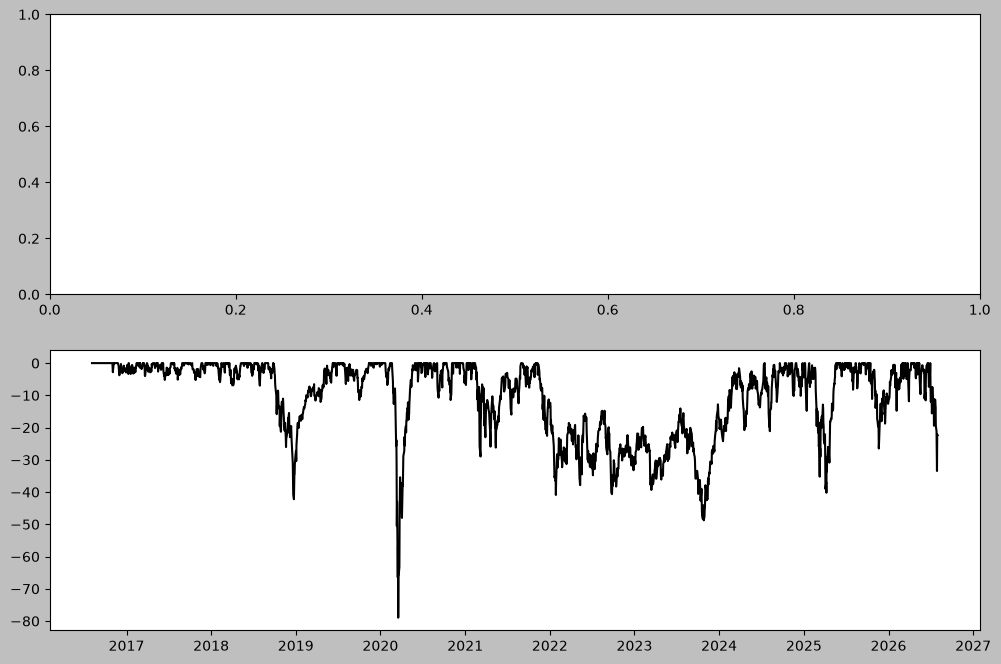

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12,8))

kwargs = dict(
    portfolio_builder=CsmPortfolioBuilder
)

# We need...
p_ec = create_portfolio_equity_curve(cfg, state, **kwargs)
p_dd = -create_portfolio_drawdown(cfg, state, **kwargs) * 100

axes[0].plot(p_ec)
axes[1].plot(-state.portfolio_drawdown*100)

In [17]:
spy_ret = (spy_close.pct_change() + 1).cumprod()